# Urban Sound Classification Using SpeechBrain

This notebook demonstrates urban sound classification using the pre-trained SpeechBrain model instead of training a custom DNN. We'll use the UrbanSound8K dataset for evaluation and comparison.

## Importing Required Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import os
import librosa
import librosa.display
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

# SpeechBrain for audio classification
import torch
import torchaudio
from speechbrain.inference import EncoderClassifier

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pickle

plt.style.use('seaborn-v0_8')

## Dataset Setup and Configuration

In [3]:
# Dataset paths
data_path = 'D:/Projects/UrbanNoiseClassifier/project/audio-classifier/data/raw/UrbanNoiseUganda61K'
csv_path = os.path.join(data_path, 'labels.csv')
audio_path = os.path.join(data_path, 'large_audio/')

# Class names for UrbanNoiseUganda61K
class_names = [
    "other",
    "car-or-truck",
    "motorvehicle-horn",
    "boda-boda-motorcycle",
    "motorvehicle-siren",
    "car-alarm",
    "mobile-music",
    "hawker-vendor",
    "community-radio",
    "religious-venue",
    "herbalists",
    "construction-site",
    "fabrication-workshop",
    "generator",
    "bar-restaurant-nightclub",
    "animal",
    "crowd-noise",
    "school",
    "street-preacher"
]

# Load the dataset metadata
data = pd.read_csv(csv_path)
print(f"Dataset loaded: {len(data)} samples")
data.head()

Dataset loaded: 61685 samples


,filename,class,class_id
0,train_0.wav,other,0
1,train_1.wav,crowd-noise,16
2,train_2.wav,car-or-truck,1
3,train_3.wav,other,0
4,train_4.wav,bar-restaurant-nightclub,14


# Exploratory Data Analysis

Let's explore the dataset structure and distribution of classes.

In [4]:
# Basic dataset information
print("Dataset Information:")
print(f"Shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"\nUnique classes: {data['class'].nunique()}")
print(f"Classes: {sorted(data['class'].unique())}")

Dataset Information:
Shape: (61685, 3)

Columns: ['filename', 'class', 'class_id']

Missing values: 0

Unique classes: 19
Classes: ['animal', 'bar-restaurant-nightclub', 'boda-boda-motorcycle', 'car-alarm', 'car-or-truck', 'community-radio', 'construction-site', 'crowd-noise', 'fabrication-workshop', 'generator', 'hawker-vendor', 'herbalists', 'mobile-music', 'motorvehicle-horn', 'motorvehicle-siren', 'other', 'religious-venue', 'school', 'street-preacher']


## Class Distribution Analysis

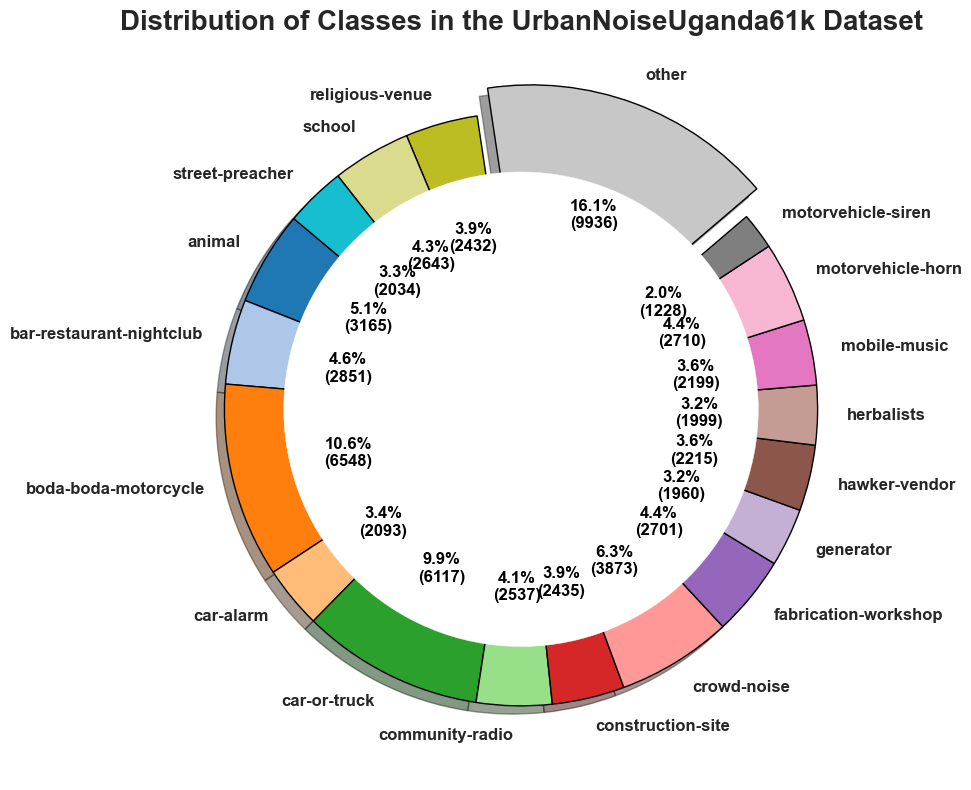


Class distribution:
animal: 3166 samples (5.1%)
bar-restaurant-nightclub: 2852 samples (4.6%)
boda-boda-motorcycle: 6549 samples (10.6%)
car-alarm: 2093 samples (3.4%)
car-or-truck: 6118 samples (9.9%)
community-radio: 2538 samples (4.1%)
construction-site: 2435 samples (3.9%)
crowd-noise: 3874 samples (6.3%)
fabrication-workshop: 2701 samples (4.4%)
generator: 1960 samples (3.2%)
hawker-vendor: 2215 samples (3.6%)
herbalists: 1999 samples (3.2%)
mobile-music: 2200 samples (3.6%)
motorvehicle-horn: 2710 samples (4.4%)
motorvehicle-siren: 1229 samples (2.0%)
other: 9936 samples (16.1%)
religious-venue: 2432 samples (3.9%)
school: 2643 samples (4.3%)
street-preacher: 2035 samples (3.3%)


In [5]:
# Class distribution visualization
class_distribution = data['class'].value_counts().sort_index()

def func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

explode = [0.1 if i == class_distribution.max() else 0 for i in class_distribution]
colors = plt.cm.tab20.colors  

wedges, texts, autotexts = plt.pie(
    class_distribution, 
    labels=class_distribution.index, 
    autopct=lambda pct: func(pct, class_distribution),
    startangle=140, 
    colors=colors, 
    explode=explode, 
    shadow=True, 
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)

plt.setp(autotexts, size=12, weight='bold', color='black')
plt.setp(texts, size=12, weight='bold')
plt.title('Distribution of Classes in the UrbanNoiseUganda61k Dataset', fontsize=20, weight='bold')

centre_circle = plt.Circle((0, 0), 0.80, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()

print("\nClass distribution:")
for class_name, count in class_distribution.items():
    print(f"{class_name}: {count} samples ({count/len(data)*100:.1f}%)")

## Audio Sample Visualization

Class: street-preacher
File: train_12146.wav
Duration: 11.10 seconds
Sample Rate: 22050 Hz


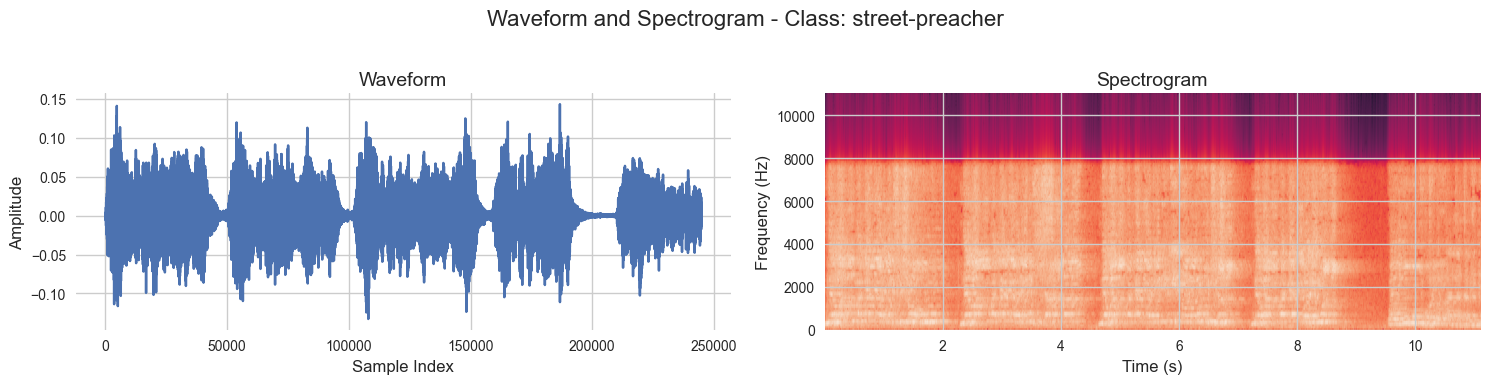

In [8]:
# Display a random audio sample with waveform and spectrogram
row = data.sample(1).iloc[0]

# Construct file path
audioFile = os.path.join(audio_path,row['filename'])

# Load audio file
waveform, sampleRate = librosa.load(audioFile)

# Display audio
print(f"Class: {row['class']}")
print(f"File: {row['filename']}")
print(f"Duration: {len(waveform)/sampleRate:.2f} seconds")
print(f"Sample Rate: {sampleRate} Hz")
ipd.display(ipd.Audio(waveform, rate=sampleRate))

# Plot configuration
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle(f'Waveform and Spectrogram - Class: {row["class"]}', fontsize=16)

# Display waveform
axs[0].plot(waveform)
axs[0].set_title('Waveform', fontsize=14)
axs[0].set_xlabel('Sample Index', fontsize=12)
axs[0].set_ylabel('Amplitude', fontsize=12)

# Display spectrogram
axs[1].specgram(waveform, Fs=sampleRate)
axs[1].set_title('Spectrogram', fontsize=14)
axs[1].set_xlabel('Time (s)', fontsize=12)
axs[1].set_ylabel('Frequency (Hz)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Mel Spectrogram Visualization

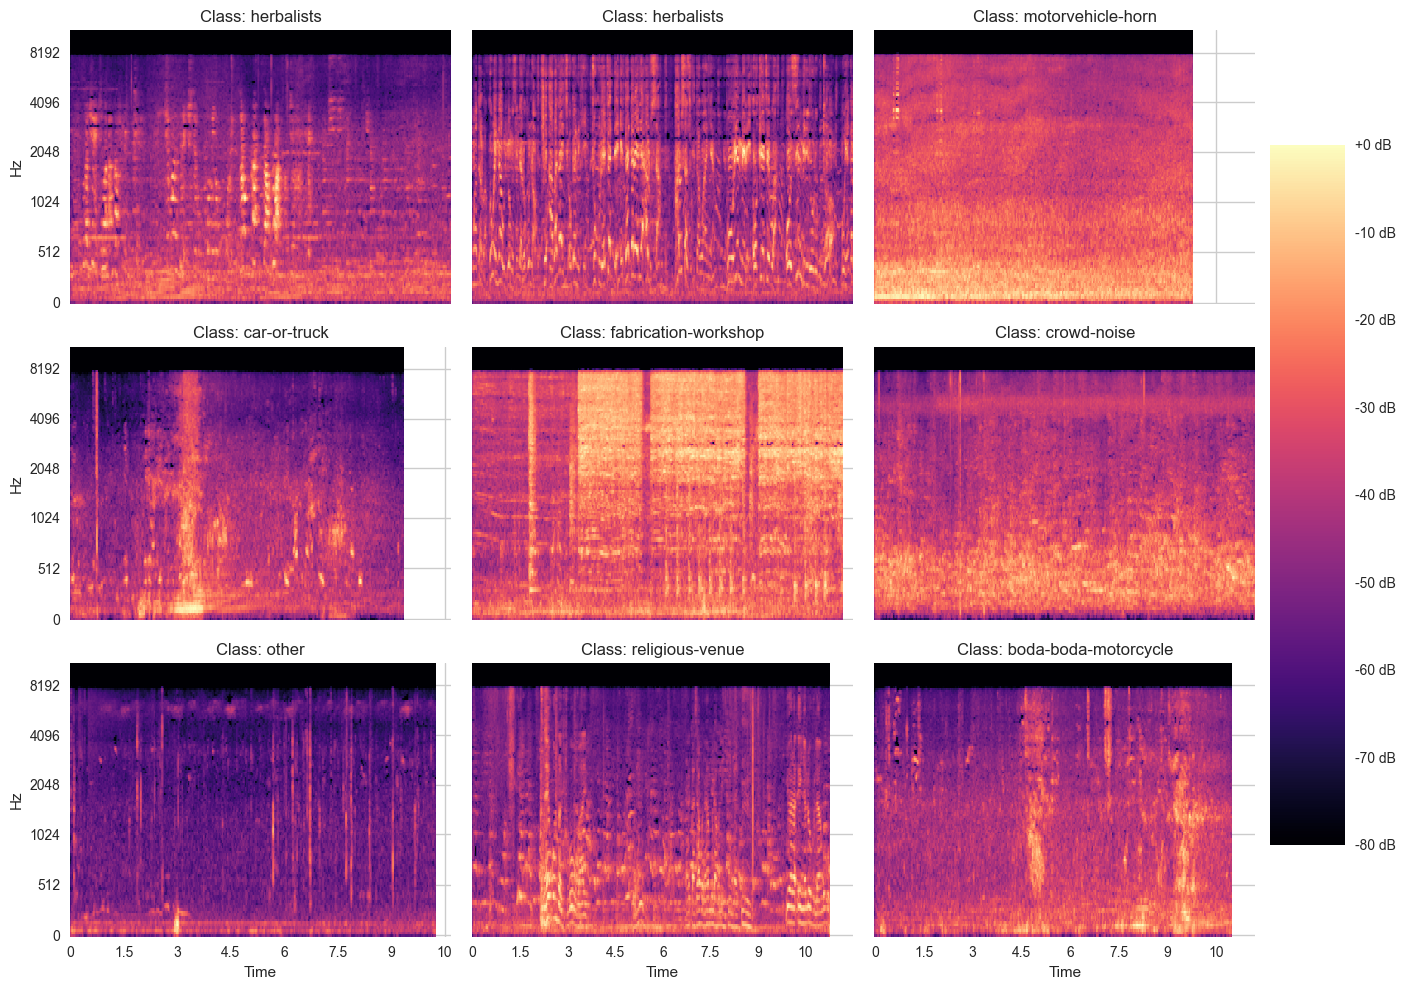

In [11]:
# Display mel spectrograms for sample files from each class
sample_files = data.sample(9)   # Randomly select 9 files for display

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex='col', sharey='row')
for i, (idx, row) in enumerate(sample_files.iterrows()):
    file_path = os.path.join(audio_path, row['filename'])
    y, sr = librosa.load(file_path)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    ax = axes[i // 3, i % 3]
    img = librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title('Class: ' + str(row['class']))
    ax.label_outer()

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()